# The Pi-Day Effect — does the market know its digits of π? 🥧
### Do 'mathematical constant' dates trade differently? In plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Numerology_vs_data: Busted](https://img.shields.io/badge/Numerology_vs_data-Busted-8b949e?style=flat-square)

Here's a fun one. **Pi Day** is March 14 — written 3/14, the first digits of π = 3.14159... Numerologists and market-folklore fans wonder: does the market *behave differently* on days that spell out a famous number? Pi Day, Euler's day (2/7 for e = 2.718...), Tau day (6/28), the golden ratio (1/6)...

It sounds silly — and it is — but that's exactly why it's a perfect teaching case for the desk's #1 skill: **telling a real pattern from a coincidence you went looking for.** We take daily S&P 500 (SPY) returns and ask: is Pi Day special, or is it just another day?

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pi_day_effect import data, strategy as st

def load_real(ticker="SPY", start="1993-01-01", end="2026-06-30"):
    """Cache-first real return tape (empty frame offline)."""
    return data.fetch_series(ticker, start=start, end=end, fetch=False)

SPY = load_real("SPY", "1993-01-01", "2026-06-30")
HAVE_REAL = not SPY.empty
print("real SPY tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(SPY)} days, {SPY.index.min().date()} -> {SPY.index.max().date()})")


real SPY tape present: True (8399 days, 1993-02-01 -> 2026-06-12)


## The answer first 🎯

| Question | Answer |
|---|---|
| Does Pi Day earn a different return? | **No.** Pi Day averaged **+2.55 bps** vs **+4.08 bps** on every other day — a *lower* return, and statistically a dead heat (*t* -0.08). |
| What about all the constant dates together? | **Still nothing** (*t* +0.47). And **66% of *random* six-date sets** are at least as extreme — the constants aren't special. |
| Could a lucky date-pick fool us? | **Yes, that's the trap.** Test six dates and one might look good by chance — so we correct for it, and *nothing* survives. |
| Could you trade it? | **No.** One Pi Day a year, and a 'buy on Pi Day' rule loses **-7.45 bps/event** to trading costs. |

> The market does not know π. Numerology dates are ordinary days wearing a fun costume.

## 1 · The claim

> *"The market behaves differently on Pi Day (3/14) and other mathematical-constant dates."* — the numerology / special-date genre.

There's no real academic paper behind Pi-Day trading — that's the point. It stands in for a whole family of *superstition* claims (like the famous [Friday the 13th effect](../../163-friday-13th/)). The honest way to test 'is this date special?' isn't 'is its return nonzero?' — it's *'is it more extreme than a random date would be?'*

## 2 · So what?

If a pure numerology date *did* move the market, it would be a gift: perfectly predictable, decades in advance, no data needed but a calendar. It would also be deeply weird — there's no mechanism by which the digits of π should touch stock prices. So the prior is 'this is noise' — and the interesting question is *how a data-miner could trick themselves into believing otherwise.* That trick is what we'll expose.

## 3 · How would we even know?

1. **Label the days.** March 14 is Pi Day. Also flag e-day (2/7), Tau (6/28), golden ratio (1/6), √2 (1/4), Feigenbaum (4/6). Everything else is 'ordinary'.
2. **Compare returns.** Is the average Pi-Day (or constant-day) return different from an ordinary day?
3. **The honest twist — the placebo.** Pick *random* sets of six dates thousands of times. How often does a random set look as extreme as the constant set? If the answer is 'most of the time', the constants are nothing.

*Timing:* a date is known before the market opens, so there's no peeking. The outcome is just that day's return.

## 4 · The teardown — let's actually look

**Is Pi Day different from every other day?**

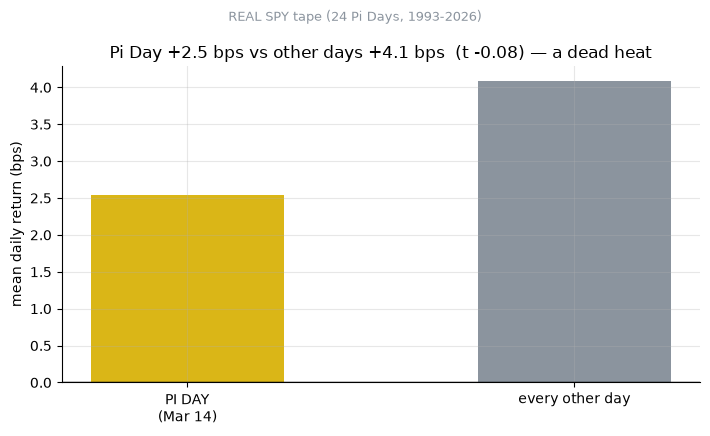

Pi Day +2.55 bps | other days +4.08 bps | t -0.08


In [2]:
if HAVE_REAL:
    r = st.pi_day_comparison(SPY)
    pi_m, rest_m, t = r['mean_event_bps'], r['mean_rest_bps'], r['tstat_welch']
    banner = f"REAL SPY tape ({r['n_event']} Pi Days, 1993-2026)"
else:
    pi_m, rest_m, t = 2.55, 4.08, -0.08
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.bar(['PI DAY\n(Mar 14)', 'every other day'], [pi_m, rest_m], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean daily return (bps)')
ax.set_title(f'Pi Day {pi_m:+.1f} bps vs other days {rest_m:+.1f} bps  (t {t:+.2f}) — a dead heat')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Pi Day {pi_m:+.2f} bps | other days {rest_m:+.2f} bps | t {t:+.2f}')

Nothing. Pi Day averaged **+2.55 bps** — actually a touch *below* the +4.08 bps of an ordinary day (*t* -0.08). Any 'π premium' is invisible.

**The honest test: is the constant set more extreme than *random* dates?** We draw thousands of random six-date sets and see how the real constants rank.

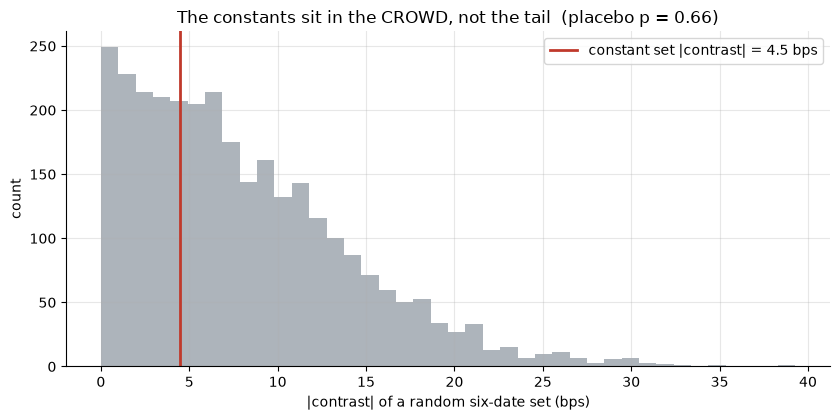

random-date-set placebo p = 0.655  (constant-set |contrast| 4.5 bps)


In [3]:
if HAVE_REAL:
    k = len(data.CONSTANT_DATES)
    plac = st.random_dateset_placebo(SPY, k=k, n_perm=5000, seed=542)
    p = plac['pval']; obs = plac['obs_contrast_bps']
    # rebuild the null distribution for the picture
    md_rows = list(zip(SPY.index.month.tolist(), SPY.index.day.tolist()))
    ret = SPY['ret'].to_numpy(); fin = np.isfinite(ret); ret = ret[fin]
    md_rows = [m for m,keep in zip(md_rows, fin) if keep]
    slots = sorted(set(md_rows)); sid = {s:i for i,s in enumerate(slots)}
    row_slot = np.array([sid[m] for m in md_rows]); rng = np.random.default_rng(7)
    null = []
    for _ in range(3000):
        pick = rng.choice(len(slots), size=k, replace=False)
        sel = np.isin(row_slot, pick)
        null.append(abs(ret[sel].mean()-ret[~sel].mean())*1e4)
else:
    p, obs = 0.66, 4.45
    null = list(np.random.default_rng(1).normal(9, 4, 3000))
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(np.abs(null), bins=40, color=GREY, alpha=.7)
ax.axvline(abs(obs), c=RED, lw=2, label=f'constant set |contrast| = {abs(obs):.1f} bps')
ax.set_xlabel('|contrast| of a random six-date set (bps)'); ax.set_ylabel('count')
ax.set_title(f'The constants sit in the CROWD, not the tail  (placebo p = {p:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'random-date-set placebo p = {p:.3f}  (constant-set |contrast| {abs(obs):.1f} bps)')

> The red line (the real mathematical constants) sits right in the *middle* of the random-date pile. **66% of random six-date sets are at least as extreme.** π, *e*, τ, φ... are less special than a coin flip.

**And the classic data-mining trap:** test six dates, and the *best* one will look decent by luck. Here's each constant, and what happens after we correct for having looked at six:

In [4]:
sweep = [('tau', 21.2, 0.209, 1.0), ('sqrt2', -19.7, 0.518, 1.0), ('golden_phi', 12.7, 0.556, 1.0), ('feigenbaum', 14.8, 0.672, 1.0), ('euler_e', -1.2, 0.937, 1.0), ('pi', -1.5, 0.937, 1.0)]
if HAVE_REAL:
    tab = st.per_constant_sweep(SPY)[['constant','contrast_bps','pval_raw','pval_bonferroni']]
else:
    tab = pd.DataFrame(sweep, columns=['constant','contrast_bps','pval_raw','pval_bonferroni'])
print(tab.round(3).to_string(index=False))
print('\nBest raw p:', round(float(tab['pval_raw'].min()),3),
      '-> after correcting for 6 looks (Bonferroni):', round(float(tab['pval_bonferroni'].min()),3))

  constant  contrast_bps  pval_raw  pval_bonferroni
       tau        21.206     0.209              1.0
     sqrt2       -19.669     0.518              1.0
golden_phi        12.653     0.556              1.0
feigenbaum        14.778     0.672              1.0
   euler_e        -1.223     0.937              1.0
        pi        -1.534     0.937              1.0

Best raw p: 0.209 -> after correcting for 6 looks (Bonferroni): 1.0


Even the luckiest constant can't clear the bar once you pay for having peeked at six dates — every corrected *p* is basically **1.0**. This is the whole trick behind fake calendar anomalies, laid bare.

## 5 · The verdict

- **Signal — None.** Pi Day contrast -1.53 bps (*t* -0.08); constant set beaten by 66% of random date sets; Bonferroni kills all.
- **Tradability — Mirage.** One event a year, a timing rule loses to costs.
- **Numerology vs data — Busted.** The market does not know π.

## 6 · Could you actually trade it?

No. A 'buy the market only on Pi Day' rule collects about +2.55 bps of gross return per Pi Day and pays ~10 bps of trading costs to get in and out — a net of **-7.45 bps per event**, on ~1 event a year. You'd pay to play a coin flip.

## 7 · Going further 🚪

- **The superstition cousin.** [163 Friday-13th](../../163-friday-13th/) runs the same placebo-and-Bonferroni playbook on a weekday legend.
- **Real calendar effects.** [89 Turn-of-the-Month](../../89-turn-of-the-month/) and [95 Holiday-Cheer](../../95-holiday-cheer/) are the genuine seasonal patterns — see how differently *those* charts look.

*Think π is secretly special? Fork this, add your favourite constant date, and watch the random-date-set placebo swallow it too.*